# Task 1 Gradient of Gaussian (GoG) filtering
## a. Compute continuous GoG-filter kernels for convolution in x- and y-direction.
Example: for standard deviation 𝜎 = 0.5 the two 2D kernels are:
𝐺_𝑥 =
\[\[00.0000 0.0001 0.0000 −0.0001 −0.0000\],
\[00.0002 0.0466 0.0000 −0.0466 −0.0002\],
\[00.0017 0.3446 0.0000 −0.3446 −0.0017\],
\[00.0002 0.0466 0.0000 −0.0466 −0.0002\],
\[00.0000 0.0001 0.0000 −0.0001 −0.0000\]\]
, 𝐺_𝑦 = 𝐺^T_𝑥

### Imports and Image Preperation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
# Load image (replace with your own if needed)
I = plt.imread("..\\ampelmaennchen.png")

# Convert to grayscale if RGB
if I.ndim == 3:
    I = I.mean(axis=2)

# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())

### Visualize Input Image

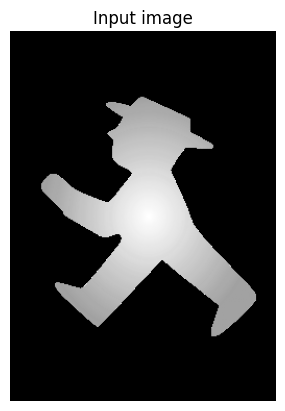

In [4]:
plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

### Kernel Construction Function

In [5]:
def gog_kernels(sigma, size):
    """
    Compute continuous Gradient-of-Gaussian kernels.
    size must be odd.
    """
    k = size // 2
    x, y = np.meshgrid(
        np.arange(-k, k + 1),
        np.arange(-k, k + 1)
    )

    G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Gx = -x / (sigma**2) * G
    Gy = -y / (sigma**2) * G

    return Gx, Gy

Example with σ = 0.5 and 5x5 kernel

In [6]:
sigma = 0.5
kernel_size = 5

Gx, Gy = gog_kernels(sigma, kernel_size)

print("Gx:\n", np.round(Gx, 4))
print("Gy:\n", np.round(Gy, 4))

Gx:
 [[ 0.000e+00  1.000e-04  0.000e+00 -1.000e-04 -0.000e+00]
 [ 2.000e-04  4.660e-02  0.000e+00 -4.660e-02 -2.000e-04]
 [ 1.700e-03  3.446e-01  0.000e+00 -3.446e-01 -1.700e-03]
 [ 2.000e-04  4.660e-02  0.000e+00 -4.660e-02 -2.000e-04]
 [ 0.000e+00  1.000e-04  0.000e+00 -1.000e-04 -0.000e+00]]
Gy:
 [[ 0.000e+00  2.000e-04  1.700e-03  2.000e-04  0.000e+00]
 [ 1.000e-04  4.660e-02  3.446e-01  4.660e-02  1.000e-04]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [-1.000e-04 -4.660e-02 -3.446e-01 -4.660e-02 -1.000e-04]
 [-0.000e+00 -2.000e-04 -1.700e-03 -2.000e-04 -0.000e+00]]


## b. Apply these filters to your input image I to derive two gradient images: 𝐼_𝑥 and 𝐼_𝑦 (one in x- and one in y-direction). 
Write a function for the convolution of the image with the kernel and ignore the boundaries of the image for simplicity, i.e. no padding needed (you may use builtin convolution functions such as convolve in NumPy or convolve2d in SciPy).

In [7]:
def convolve_valid(image, kernel):
    return signal.convolve2d(image, kernel, mode="valid")

In [8]:
Ix = convolve_valid(I, Gx)
Iy = convolve_valid(I, Gy)


### c. Compute and visualize the gradient magnitude image 𝐺:
𝐺 = sqrt(𝐼^2_𝑥 + 𝐼^2_𝑦)

In [9]:
Gmag = np.sqrt(Ix**2 + Iy**2)

### Visualization of the Images

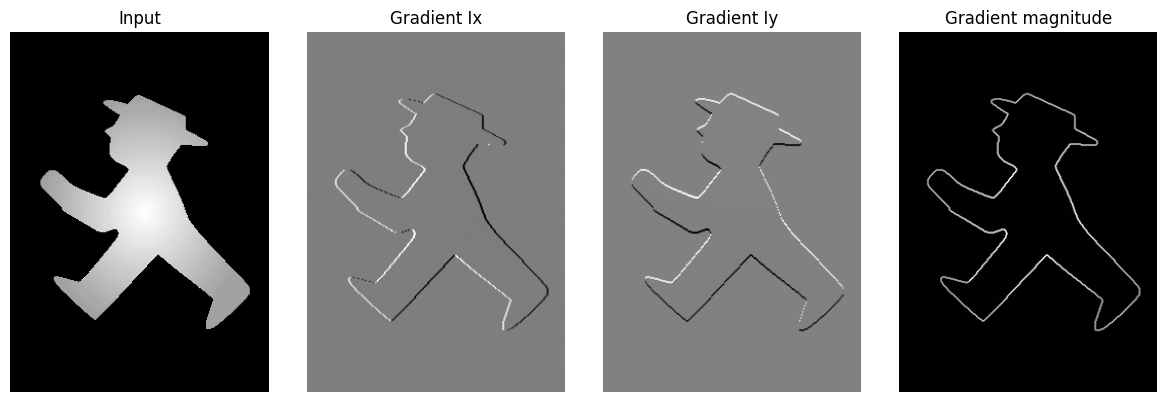

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(I, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Ix, cmap="gray")
plt.title("Gradient Ix")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(Iy, cmap="gray")
plt.title("Gradient Iy")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(Gmag, cmap="gray")
plt.title("Gradient magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()